In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os

print(os.listdir())


['.config', 'titanic dataset codsoft task 1.zip', 'sample_data']


In [4]:
import zipfile
import os

zip_file = "titanic dataset codsoft task 1.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("titanic_data")

print("ZIP extracted successfully!")
print(os.listdir("titanic_data"))


ZIP extracted successfully!
['Titanic-Dataset.csv']


In [5]:
import os

for root, dirs, files in os.walk("titanic_data"):
    print("Folder:", root)
    print("Files:", files)

Folder: titanic_data
Files: ['Titanic-Dataset.csv']


In [6]:
import pandas as pd

df = pd.read_csv("titanic_data/Titanic-Dataset.csv")

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [7]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
print("\nData Information:")
df.info()


Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [11]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [12]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [13]:
df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

print(df.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


In [15]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [17]:
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

print(df.head())

   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500      True       False   
1         1       1  38.0      1      0  71.2833     False       False   
2         1       3  26.0      0      0   7.9250     False       False   
3         1       1  35.0      1      0  53.1000     False       False   
4         0       3  35.0      0      0   8.0500      True       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


In [18]:
print(df.dtypes)

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [19]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True

Target:
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [23]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0]


In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.8100558659217877
Accuracy Percentage: 81.00558659217877 %


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



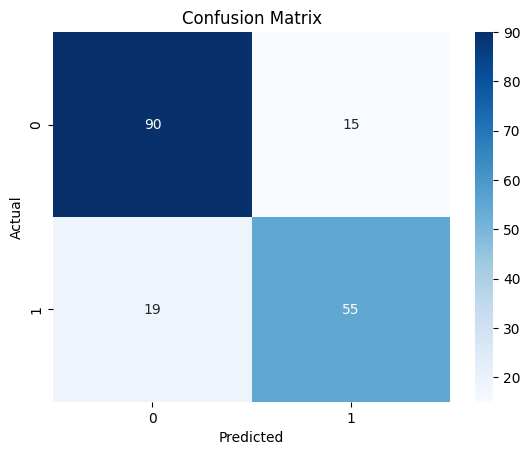

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results.head(20))

    Actual  Predicted
0        1          0
1        0          0
2        0          0
3        1          1
4        1          1
5        1          1
6        1          1
7        0          0
8        1          1
9        1          1
10       0          0
11       0          0
12       0          0
13       0          0
14       0          0
15       1          1
16       1          0
17       1          1
18       0          0
19       0          0


In [28]:
import joblib

joblib.dump(model, "titanic_survival_model.pkl")

print("Model saved successfully!")

Model saved successfully!


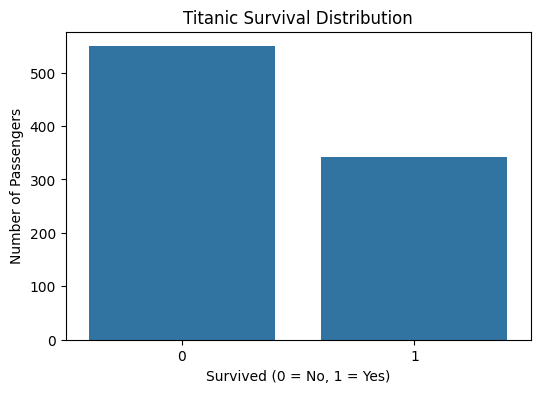

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Survived", data=df)
plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

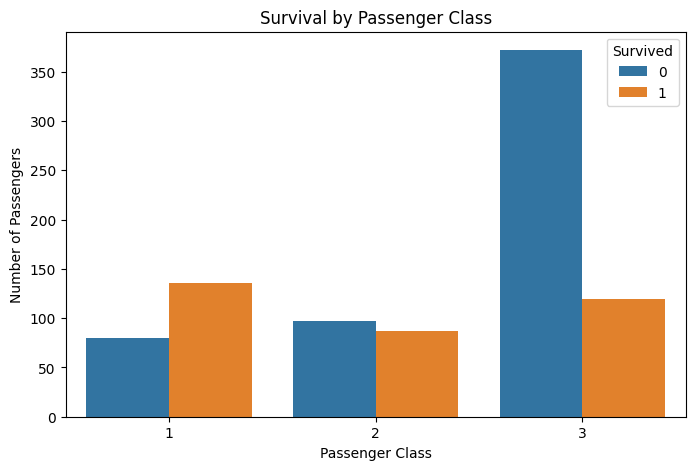

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

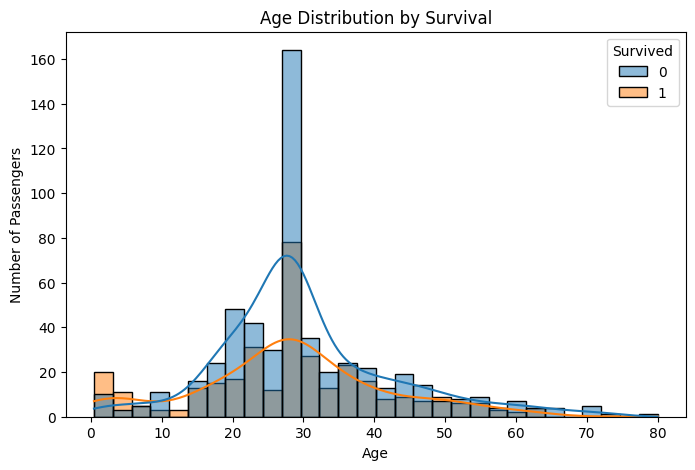

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Survived", kde=True)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

In [32]:
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 81.01%


In [33]:
new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [10],
    "Sex_male": [1],
    "Embarked_Q": [0],
    "Embarked_S": [1]
})

prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("Prediction: Passenger would likely SURVIVE")
else:
    print("Prediction: Passenger would likely NOT SURVIVE")

Prediction: Passenger would likely NOT SURVIVE
